In [15]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import dbof.dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.dataset_creation.zarr_grid_global    as zarr_grid
import dbof.io.filesystems as filesystems

# Assess GLOBAL DEPTH dataset

This notebook inspects any subset written by `generate-global-depth`.
Set `SUBSET` below to choose which subset to inspect.

All subsets are surface-level `(T, C, H, W)` and use `GlobalZarrDatasetReader`.
Depth-derived diagnostics are computed lazily from the full water column and
reduced to 2D before writing — the Zarr stores contain only surface fields.

Fields with four depth variants use the suffixes:
- `_sfc` — z = 0 (surface, k=0)
- `_z25m` — z = 25 m (fixed depth)
- `_mld` — interpolated to the mixed-layer depth
- `_mld_mean` — thickness-weighted mean over 0 <= z <= MLD

| Subset | Channels | Output zarr |
|---|---|---|
| `stratification` | `mixed_layer_depth`, `N2_sfc/z25m/mld/mld_mean`, `ml_heat_content` | `stratification.zarr` |
| `vertical_shear` | `vertical_shear_sfc/z25m/mld/mld_mean`, `Ri_sfc/z25m/mld/mld_mean` | `vertical_shear.zarr` |
| `mixing_parameters` | `Fr_sfc/z25m/mld/mld_mean`, `Ro_sfc/z25m/mld/mld_mean`, `Burger_number` | `mixing_parameters.zarr` |
| `ertel_pv` | `ertel_pv[_vertical/_tilt]_sfc/z25m/mld/mld_mean` (12 channels) | `ertel_pv.zarr` |
| `vertical_fluxes` | `uB/vB/wB_sfc/z25m/mld/mld_mean` (12 channels) | `vertical_fluxes.zarr` |
| `surface_wind` | `wind_stress_curl`, `ekman_pumping`, `u_ekman`, `v_ekman` | `surface_wind.zarr` |
| `native_surface` | `Theta`, `Salt`, `Eta`, `U`, `V`, `W` | `native_surface.zarr` |
| `eta` | `Eta` | `eta.zarr` |
| `icearea` | `SIarea` | `icearea.zarr` |
| `windstress` | `oceTAUX`, `oceTAUY` | `windstress.zarr` |

## Dataset access config

Parameters are loaded from `configs/data_access/global_depth.yaml`.
Update `run_id` in that file to match the session you want to inspect.

In [16]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
# SUBSET options:
#   Depth-derived (output as 2D surface):
#     'stratification'    — MLD, N², heat content
#     'vertical_shear'    — |S|, Ri at 4 depths
#     'mixing_parameters' — Fr, Ro at 4 depths + Burger number
#     'ertel_pv'          — Ertel PV terms at 4 depths
#     'buoyancy_fluxes'   — uB, vB, wB at 4 depths
#     'surface_wind'      — wind stress curl, Ekman pumping/transport
#   Surface-only model variables:
#     'native_surface', 'eta', 'icearea', 'windstress'
# ════════════════════════════════════════════════════════════════════════════════
SUBSET = 'stratification'
# ════════════════════════════════════════════════════════════════════════════════

# All subsets in this pipeline are surface-level (T, C, H, W).
IS_SURFACE_ONLY = True

path_to_config = "../../configs/data_access/global_depth.yaml"
with open(path_to_config) as f:
    cfg = yaml.safe_load(f)

data_cfg = cfg["data_access"]
grid_cfg = cfg["grid_access"]

bucket      = data_cfg["bucket"]
folder      = data_cfg["folder"]
s3_endpoint = data_cfg["s3_endpoint"]
run_id      = data_cfg["run_id"]

subset_cfg       = data_cfg["subsets"][SUBSET]
dataset_name     = subset_cfg["dataset_name"]
feature_channels = subset_cfg["feature_channels"]

grid_bucket       = grid_cfg["bucket"]
grid_folder       = grid_cfg["folder"]
grid_s3_endpoint  = grid_cfg["s3_endpoint"]
grid_dataset_name = grid_cfg["dataset_name"]

print(f"Subset        : {SUBSET}")
print(f"Snapshot      : s3://{bucket}/{folder}/{run_id}/{dataset_name}")
print(f"Channels      : {feature_channels}")
print(f"Grid          : s3://{grid_bucket}/{grid_folder}/{grid_dataset_name}")

Subset        : stratification
Snapshot      : s3://dbof/properties/testing_015/stratification.zarr
Channels      : ['mixed_layer_depth', 'N2_sfc', 'N2_z25m', 'N2_mld', 'N2_mld_mean', 'ml_heat_content']
Grid          : s3://dbof/native_grid_dbof_training_data/llc4320_grid.zarr


# Load the data

In [17]:
# ── Reader ──────────────────────────────────────────────────────────────────────
fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name=dataset_name,
    fs=fs,
)
print(reader)
print(f"Channels  : {reader.channel_names}")
print(f"Timesteps : {reader.n_timesteps}")
print(f"Shape     : {reader.shape}  (T, C, H, W)")

# ── Grid reader ────────────────────────────────────────────────────────────────
fs_grid, _ = filesystems.create_s3_filesystems(grid_s3_endpoint)

grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=grid_bucket,
    folder=grid_folder,
    dataset_name=grid_dataset_name,
    fs=fs_grid,
)
print(grid_reader)

XC = grid_reader.lon
YC = grid_reader.lat
print(f"Grid loaded: XC {XC.shape}, lon [{XC.min():.1f}, {XC.max():.1f}]  "
      f"YC {YC.shape}, lat [{YC.min():.1f}, {YC.max():.1f}]")

DS_GLOBAL = 20
XC_g = XC[::DS_GLOBAL, ::DS_GLOBAL]
YC_g = YC[::DS_GLOBAL, ::DS_GLOBAL]

Channels  : ['mixed_layer_depth', 'N2_sfc', 'N2_z25m', 'N2_mld', 'N2_mld_mean', 'ml_heat_content']
Timesteps : 1
Shape     : (1, 6, 12960, 17280)  (T, C, H, W)
GlobalGridZarrReader(shape=(12960, 17280), variables=['XC', 'YC', 'rA', 'Depth', 'SN', 'CS', 'hFacC', 'dxC', 'dyG', 'hFacW', 'rAw', 'dyC', 'dxG', 'hFacS', 'rAs', 'rAz', 'XG', 'YG', 'lat', 'lon'])
Grid loaded: XC (12960, 17280), lon [-180.0, 180.0]  YC (12960, 17280), lat [-90.0, 72.0]


In [18]:
print(f"n_timesteps : {reader.n_timesteps}")
print(f"time array  : {reader.time[:]}")

n_timesteps : 1
time array  : [1463616]


# Colormap / label configuration

All channels are registered here.  Only channels present in the selected subset
will be plotted.

In [19]:
# ── Colormap and physical label for every possible channel ────────────────────
# cmo colormaps: https://matplotlib.org/cmocean/
CMAP_CFG = {
    # --- native model variables ---
    'Theta':    ('thermal', 'Potential temperature (°C)'),
    'Salt':     ('haline',  'Salinity (psu)'),
    'U':        ('balance', 'Zonal velocity U (m s⁻¹)'),
    'V':        ('balance', 'Meridional velocity V (m s⁻¹)'),
    'W':        ('balance', 'Vertical velocity W (m s⁻¹)'),
    'Eta':      ('gray',    'Sea surface height (m)'),
    'SIarea':   ('ice',     'Sea-ice area fraction (0–1)'),
    'oceTAUX':  ('balance', 'Zonal wind stress τˣ (N m⁻²)'),
    'oceTAUY':  ('balance', 'Meridional wind stress τʸ (N m⁻²)'),

    # --- stratification ---
    'mixed_layer_depth': ('deep',    'Mixed layer depth (m)'),
    'N2_sfc':            ('tempo',   'N² surface (s⁻²)'),
    'N2_z25m':           ('tempo',   'N² at 25 m (s⁻²)'),
    'N2_mld':            ('tempo',   'N² at MLD (s⁻²)'),
    'N2_mld_mean':       ('tempo',   'N² ML mean (s⁻²)'),
    'N2_mld_base':       ('tempo',   'N² at MLD base (s⁻²)'),
    'ml_heat_content':   ('thermal', 'ML heat content (J m⁻²)'),

    # --- vertical shear ---
    'vertical_shear_sfc':      ('speed', 'Shear |S| surface (s⁻¹)'),
    'vertical_shear_z25m':     ('speed', 'Shear |S| at 25 m (s⁻¹)'),
    'vertical_shear_mld':      ('speed', 'Shear |S| at MLD (s⁻¹)'),
    'vertical_shear_mld_mean': ('speed', 'Shear |S| ML mean (s⁻¹)'),
    'Ri_sfc':                  ('curl',  'Ri surface'),
    'Ri_z25m':                 ('curl',  'Ri at 25 m'),
    'Ri_mld':                  ('curl',  'Ri at MLD'),
    'Ri_mld_mean':             ('curl',  'Ri ML mean'),

    # --- mixing parameters ---
    'Fr_sfc':        ('amp',     'Fr surface'),
    'Fr_z25m':       ('amp',     'Fr at 25 m'),
    'Fr_mld':        ('amp',     'Fr at MLD'),
    'Fr_mld_mean':   ('amp',     'Fr ML mean'),
    'Ro_sfc':        ('balance', 'Ro surface'),
    'Ro_z25m':       ('balance', 'Ro at 25 m'),
    'Ro_mld':        ('balance', 'Ro at MLD'),
    'Ro_mld_mean':   ('balance', 'Ro ML mean'),
    'Burger_number': ('matter',  'Burger number'),

    # --- Ertel PV ---
    'ertel_pv_sfc':              ('curl', 'Ertel PV surface (s⁻³)'),
    'ertel_pv_z25m':             ('curl', 'Ertel PV at 25 m (s⁻³)'),
    'ertel_pv_mld':              ('curl', 'Ertel PV at MLD (s⁻³)'),
    'ertel_pv_mld_mean':         ('curl', 'Ertel PV ML mean (s⁻³)'),
    'ertel_pv_vertical_sfc':     ('curl', 'PV vertical surface (s⁻³)'),
    'ertel_pv_vertical_z25m':    ('curl', 'PV vertical at 25 m (s⁻³)'),
    'ertel_pv_vertical_mld':     ('curl', 'PV vertical at MLD (s⁻³)'),
    'ertel_pv_vertical_mld_mean':('curl', 'PV vertical ML mean (s⁻³)'),
    'ertel_pv_tilt_sfc':         ('curl', 'PV tilt surface (s⁻³)'),
    'ertel_pv_tilt_z25m':        ('curl', 'PV tilt at 25 m (s⁻³)'),
    'ertel_pv_tilt_mld':         ('curl', 'PV tilt at MLD (s⁻³)'),
    'ertel_pv_tilt_mld_mean':    ('curl', 'PV tilt ML mean (s⁻³)'),

    # --- advective buoyancy fluxes ---
    'uB_sfc':      ('balance', 'uB surface (m² s⁻³)'),
    'uB_z25m':     ('balance', 'uB at 25 m (m² s⁻³)'),
    'uB_mld':      ('balance', 'uB at MLD (m² s⁻³)'),
    'uB_mld_mean': ('balance', 'uB ML mean (m² s⁻³)'),
    'vB_sfc':      ('balance', 'vB surface (m² s⁻³)'),
    'vB_z25m':     ('balance', 'vB at 25 m (m² s⁻³)'),
    'vB_mld':      ('balance', 'vB at MLD (m² s⁻³)'),
    'vB_mld_mean': ('balance', 'vB ML mean (m² s⁻³)'),
    'wB_sfc':      ('balance', 'wB surface (m² s⁻³)'),
    'wB_z25m':     ('balance', 'wB at 25 m (m² s⁻³)'),
    'wB_mld':      ('balance', 'wB at MLD (m² s⁻³)'),
    'wB_mld_mean': ('balance', 'wB ML mean (m² s⁻³)'),

    # --- surface wind diagnostics ---
    'wind_stress_curl': ('balance', 'Wind stress curl (N m⁻³)'),
    'ekman_pumping':    ('balance', 'Ekman pumping (m s⁻¹)'),
    'u_ekman':          ('balance', 'Ekman transport u (m s⁻¹)'),
    'v_ekman':          ('balance', 'Ekman transport v (m s⁻¹)'),
}

channels_to_plot = [ch for ch in reader.channel_names if ch in CMAP_CFG]
print(f"Plotting {len(channels_to_plot)} channels: {channels_to_plot}")

# Channels that should use a logarithmic colour scale (N² is positive-definite
# in stably-stratified water and spans several orders of magnitude).
LOG_SCALE_CHANNELS = {k for k in CMAP_CFG if k.startswith('N2_')}

# Diverging colormaps that should be centred at zero so that negatives and
# positives get distinct colours with white at the midpoint.
DIVERGING_CMAPS = {'balance', 'curl'}

Plotting 6 channels: ['mixed_layer_depth', 'N2_sfc', 'N2_z25m', 'N2_mld', 'N2_mld_mean', 'ml_heat_content']


## Notes

All output subsets are 2D surface-level fields `(T, C, H, W)`.
Depth-derived diagnostics (MLD, N², shear, PV, etc.) were computed from the
full water column and reduced to 2D before writing.  There is no K axis to
select.

In [20]:
print(f"Subset '{SUBSET}' — all channels are 2D surface fields.")
print(f"Available channels: {reader.channel_names}")

Subset 'stratification' — all channels are 2D surface fields.
Available channels: ['mixed_layer_depth', 'N2_sfc', 'N2_z25m', 'N2_mld', 'N2_mld_mean', 'ml_heat_content']


## Single-channel global map at a chosen depth

/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


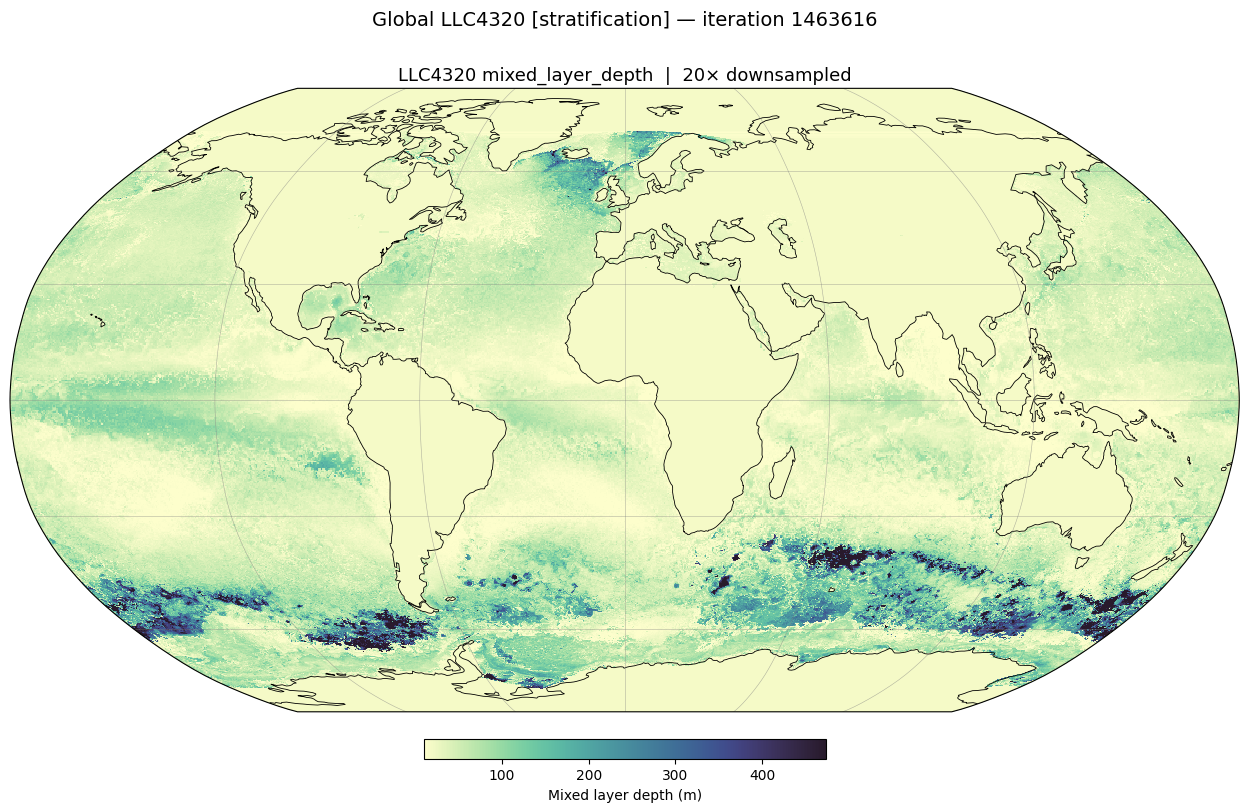

In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
target   = channels_to_plot[0]
timestep = 0
# ════════════════════════════════════════════════════════════════════════════════

arr_ds = reader.get_channel_snapshot(timestep, target)[::DS_GLOBAL, ::DS_GLOBAL]

cmap_name, label = CMAP_CFG[target]
cmap = getattr(cmo, cmap_name)
finite = arr_ds[np.isfinite(arr_ds)]
vmin, vmax = np.nanpercentile(finite, [1, 99])
if target in LOG_SCALE_CHANNELS:
    pos = finite[finite > 0]
    vmin, vmax = np.nanpercentile(pos, [1, 99]) if pos.size > 0 else (1e-8, 1e-3)
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
elif cmap_name in DIVERGING_CMAPS:
    vlim = max(abs(vmin), abs(vmax))
    norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vlim, vmax=vlim)
else:
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(16, 8))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

im = ax.pcolormesh(XC_g, YC_g, arr_ds,
                   cmap=cmap, norm=norm,
                   transform=ccrs.PlateCarree(),
                   shading='nearest')
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='k')
ax.gridlines(linewidth=0.4, color='gray', alpha=0.6)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, shrink=0.7,
             label=label, orientation='horizontal')
ax.set_title(
    f'LLC4320 {target}  |  {DS_GLOBAL}× downsampled',
    fontsize=13,
)
plt.suptitle(
    f'Global LLC4320 [{SUBSET}] — iteration {reader.time[timestep]}',
    fontsize=14, y=1.01,
)
plt.tight_layout()
plt.show()

## All-channels global overview at a chosen depth

/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/lhoffma2/miniforge

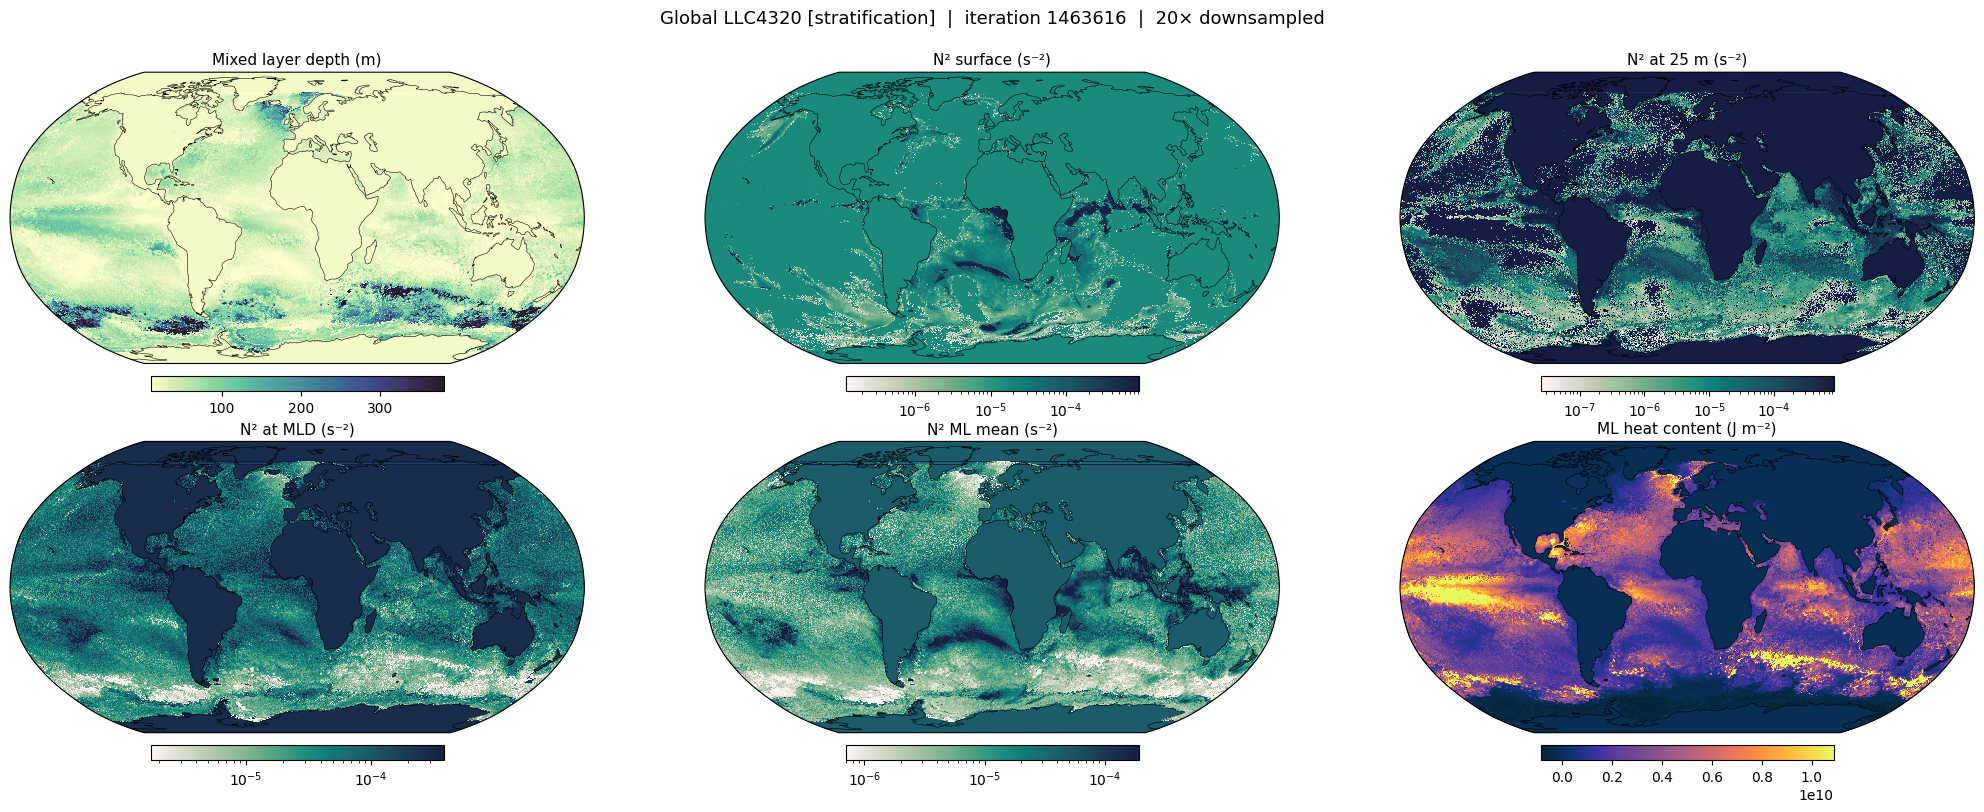

In [21]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
timestep = 0
ncols    = 3
# ════════════════════════════════════════════════════════════════════════════════

nrows = int(np.ceil(len(channels_to_plot) / ncols))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 7, nrows * 4),
    subplot_kw={'projection': ccrs.Robinson()},
)
axes = np.array(axes).flatten()

for ax, ch in zip(axes, channels_to_plot):
    arr = reader.get_channel_snapshot(timestep, ch)[::DS_GLOBAL, ::DS_GLOBAL]
    cmap_name, label = CMAP_CFG[ch]
    cmap = getattr(cmo, cmap_name)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        ax.set_visible(False)
        continue
    vmin, vmax = np.nanpercentile(finite, [2, 98])
    if ch in LOG_SCALE_CHANNELS:
        pos = finite[finite > 0]
        vmin, vmax = np.nanpercentile(pos, [2, 98]) if pos.size > 0 else (1e-8, 1e-3)
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    elif cmap_name in DIVERGING_CMAPS:
        vlim = max(abs(vmin), abs(vmax))
        norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vlim, vmax=vlim)
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    im = ax.pcolormesh(XC_g, YC_g, arr,
                       cmap=cmap, norm=norm,
                       transform=ccrs.PlateCarree(),
                       shading='nearest')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k')
    ax.set_title(label, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85,
                 orientation='horizontal')

for ax in axes[len(channels_to_plot):]:
    ax.set_visible(False)

plt.suptitle(
    f'Global LLC4320 [{SUBSET}]  |  '
    f'iteration {reader.time[timestep]}  |  {DS_GLOBAL}× downsampled',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## Compare depth variants of the same field

For fields with `_sfc`, `_z25m`, `_mld`, `_mld_mean` suffixes, plot all four
side by side to see how the field varies across depth definitions.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
# Set BASE_FIELD to any field that has _sfc/_z25m/_mld/_mld_mean variants.
# Examples: 'N2', 'vertical_shear', 'Ri', 'Fr', 'Ro', 'ertel_pv',
#           'ertel_pv_vertical', 'ertel_pv_tilt', 'uB', 'vB', 'wB'
BASE_FIELD = 'N2'
timestep   = 0
# ════════════════════════════════════════════════════════════════════════════════

depth_suffixes = ['sfc', 'z25m', 'mld', 'mld_mean']
variant_channels = [f"{BASE_FIELD}_{s}" for s in depth_suffixes]
available = [ch for ch in variant_channels if ch in reader.channel_names]

if not available:
    print(f"No depth variants found for '{BASE_FIELD}' in this subset.")
    print(f"Available channels: {reader.channel_names}")
else:
    ncols_v = len(available)
    fig, axes = plt.subplots(
        1, ncols_v,
        figsize=(ncols_v * 6, 5),
        subplot_kw={'projection': ccrs.Robinson()},
    )
    if ncols_v == 1:
        axes = [axes]

    for ax, ch in zip(axes, available):
        arr = reader.get_channel_snapshot(timestep, ch)[::DS_GLOBAL, ::DS_GLOBAL]
        cmap_name, label = CMAP_CFG.get(ch, ('viridis', ch))
        cmap = getattr(cmo, cmap_name, plt.cm.viridis)
        finite = arr[np.isfinite(arr)]
        if finite.size == 0:
            ax.set_visible(False)
            continue
        vmin, vmax = np.nanpercentile(finite, [2, 98])
        if ch in LOG_SCALE_CHANNELS:
            pos = finite[finite > 0]
            vmin, vmax = np.nanpercentile(pos, [2, 98]) if pos.size > 0 else (1e-8, 1e-3)
            norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
        elif cmap_name in DIVERGING_CMAPS:
            vlim = max(abs(vmin), abs(vmax))
            norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vlim, vmax=vlim)
        else:
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        im = ax.pcolormesh(XC_g, YC_g, arr,
                           cmap=cmap, norm=norm,
                           transform=ccrs.PlateCarree(),
                           shading='nearest')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k')
        ax.set_title(label, fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85,
                     orientation='horizontal')

    plt.suptitle(
        f'{BASE_FIELD} depth variants  |  iteration {reader.time[timestep]}  |  {DS_GLOBAL}× downsampled',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()

## Per-channel statistics

Quick sanity check: print min/max/mean/NaN fraction for each channel.

In [ ]:
timestep = 0
print(f"{'Channel':<30s}  {'Min':>12s}  {'Max':>12s}  {'Mean':>12s}  {'NaN %':>7s}")
print("─" * 80)
for ch in reader.channel_names:
    arr = reader.get_channel_snapshot(timestep, ch)
    finite = arr[np.isfinite(arr)]
    nan_pct = 100.0 * (1.0 - finite.size / arr.size)
    if finite.size > 0:
        print(f"{ch:<30s}  {finite.min():>12.4g}  {finite.max():>12.4g}  {finite.mean():>12.4g}  {nan_pct:>6.1f}%")
    else:
        print(f"{ch:<30s}  {'all NaN':>12s}  {'':>12s}  {'':>12s}  {nan_pct:>6.1f}%")

In [ ]:
# (Vertical profile cell removed — all subsets are 2D surface fields.
#  The statistics table above replaces this cell.)

## Regional plots

### Region selection by lat/lon

The grid (XC, YC) is loaded — you can select any region by geographic
coordinates.  The nearest pixel to your requested **(lat, lon)** centre is
found automatically, and the bounding box is derived from an approximate
km-to-pixel conversion (LLC4320 native resolution ≈ 1/48° ≈ 2.3 km at
mid-latitudes).

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS — edit these to choose your region
# ════════════════════════════════════════════════════════════════════════════════
LAT_CENTER = 36.0       # degrees north
LON_CENTER = -72.0      # degrees east  (use negative for west)
HALF_H_KM  = 1000.0     # approximate half-height of region (km)
HALF_W_KM  = 2000.0     # approximate half-width  of region (km)
# ════════════════════════════════════════════════════════════════════════════════

H, W = reader.rectangular_shape

lon_q = LON_CENTER % 360 if float(XC.max()) > 180 else LON_CENTER

dist = np.sqrt((XC - lon_q) ** 2 + (YC - LAT_CENTER) ** 2)
cy, cx = np.unravel_index(int(np.nanargmin(dist)), dist.shape)
print(f"Nearest pixel to ({LAT_CENTER}°N, {LON_CENTER}°E): y={cy}, x={cx}  "
      f"[actual: lat={float(YC[cy,cx]):.3f}°N, lon={float(XC[cy,cx]):.3f}°E]")

KM_PER_PIX = 2.3
HALF_H_PIX = int(HALF_H_KM / KM_PER_PIX)
HALF_W_PIX = int(HALF_W_KM / KM_PER_PIX)

y0 = max(0, cy - HALF_H_PIX)
y1 = min(H, cy + HALF_H_PIX)
x0 = max(0, cx - HALF_W_PIX)
x1 = min(W, cx + HALF_W_PIX)

XC_reg = XC[y0:y1, x0:x1]
YC_reg = YC[y0:y1, x0:x1]

print(f"Region: rows [{y0}:{y1}], cols [{x0}:{x1}]  ->  {y1-y0} x {x1-x0} pixels")
print(f"Geographic extent: lon [{float(XC_reg.min()):.2f}, {float(XC_reg.max()):.2f}]  "
      f"lat [{float(YC_reg.min()):.2f}, {float(YC_reg.max()):.2f}]")

In [ ]:
# ── Global context map with selected region outlined ──────────────────────────
context_ch = channels_to_plot[0]
ctx_ds = reader.get_channel_snapshot(0, context_ch)[::DS_GLOBAL, ::DS_GLOBAL]

ctx_cmap_name, ctx_label = CMAP_CFG[context_ch]
vmin_c, vmax_c = np.nanpercentile(ctx_ds[np.isfinite(ctx_ds)], [2, 98])

fig = plt.figure(figsize=(18, 9))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

im = ax.pcolormesh(XC_g, YC_g, ctx_ds,
                   cmap=getattr(cmo, ctx_cmap_name), vmin=vmin_c, vmax=vmax_c,
                   transform=ccrs.PlateCarree(), shading='nearest')
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.04, shrink=0.7,
             label=ctx_label, orientation='horizontal')
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='k')
ax.gridlines(linewidth=0.4, color='gray', alpha=0.5)

pc = ccrs.PlateCarree()
ax.plot(XC[y0, x0:x1],   YC[y0, x0:x1],   'r-', lw=2, transform=pc)
ax.plot(XC[y1-1, x0:x1], YC[y1-1, x0:x1], 'r-', lw=2, transform=pc)
ax.plot(XC[y0:y1, x0],   YC[y0:y1, x0],   'r-', lw=2, transform=pc)
ax.plot(XC[y0:y1, x1-1], YC[y0:y1, x1-1], 'r-', lw=2, transform=pc)
ax.plot(float(XC[cy, cx]), float(YC[cy, cx]),
        'r+', markersize=14, markeredgewidth=2.5, transform=pc, zorder=6)

ax.set_title(
    f'Global [{SUBSET}] — {context_ch} ({DS_GLOBAL}× downsampled) — selected region (red box)\n'
    f'centre: ({LAT_CENTER}°N, {LON_CENTER}°E)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [ ]:
# ── Regional subplots — all channels ──────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
timestep = 0
ncols    = 3
# ════════════════════════════════════════════════════════════════════════════════

nrows = int(np.ceil(len(channels_to_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 6))
axes = np.array(axes).flatten()

for ax, ch in zip(axes, channels_to_plot):
    arr = reader.get_channel_snapshot(timestep, ch)[y0:y1, x0:x1]
    cmap_name, label = CMAP_CFG[ch]
    cmap = getattr(cmo, cmap_name)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        ax.set_visible(False)
        continue
    vmin, vmax = np.nanpercentile(finite, [1, 99])
    if ch in LOG_SCALE_CHANNELS:
        pos = finite[finite > 0]
        vmin, vmax = np.nanpercentile(pos, [1, 99]) if pos.size > 0 else (1e-8, 1e-3)
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    elif cmap_name in DIVERGING_CMAPS:
        vlim = max(abs(vmin), abs(vmax))
        norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vlim, vmax=vlim)
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    im = ax.pcolormesh(XC_reg, YC_reg, arr,
                       cmap=cmap, norm=norm,
                       shading='nearest')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Longitude (°E)', fontsize=9)
    ax.set_ylabel('Latitude (°N)',  fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.9)

for ax in axes[len(channels_to_plot):]:
    ax.set_visible(False)

plt.suptitle(
    f'Regional [{SUBSET}]  |  '
    f'centre ({LAT_CENTER}°N, {LON_CENTER}°E)  |  '
    f'lon [{float(XC_reg.min()):.1f}°, {float(XC_reg.max()):.1f}°]  '
    f'lat [{float(YC_reg.min()):.1f}°, {float(YC_reg.max()):.1f}°]',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()